/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


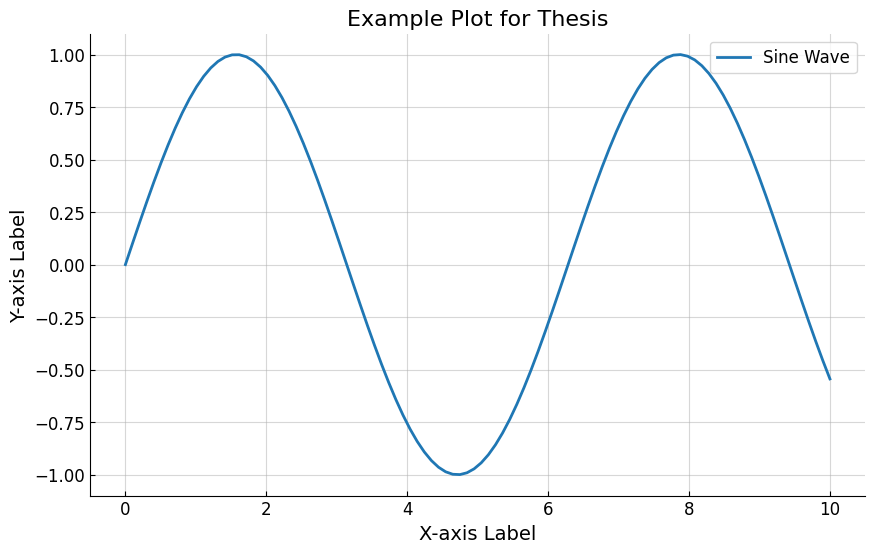

In [1]:
import matplotlib.pyplot as plt
import sys

sys.path += [".."]
# Custom configuration for Matplotlib plots
plt.rcParams.update({
    'figure.figsize': (10, 6),           # Figure size
    'axes.titlesize': 16,                # Title font size
    'axes.labelsize': 14,                # Axes labels font size
    'xtick.labelsize': 12,               # X-axis tick labels font size
    'ytick.labelsize': 12,               # Y-axis tick labels font size
    'legend.fontsize': 12,               # Legend font size
    'lines.linewidth': 2,                # Line width
    'lines.markersize': 6,               # Marker size
    'axes.grid': True,                   # Show grid
    'grid.alpha': 0.5,                   # Grid transparency
    'legend.loc': 'best',                # Legend location
    'font.family': 'sans-serif',              # Font family
    'font.serif': ['Times New Roman'],   # Specific font
    'axes.spines.top': False,            # Disable top spine
    'axes.spines.right': False,          # Disable right spine
    'xtick.direction': 'in',             # X-axis tick direction
    'ytick.direction': 'in',             # Y-axis tick direction
    'savefig.dpi': 300,                  # Resolution of saved figures
    'savefig.format': 'png'              # Format of saved figures
})

# Example plot to demonstrate the configuration
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y, label='Sine Wave')
plt.title('Example Plot for Thesis')
plt.xlabel('X-axis Label')
plt.ylabel('Y-axis Label')
plt.legend()
# plt.savefig('example_plot.png')  # Save the plot
plt.show()


#BSPLINES

<Figure size 1000x600 with 0 Axes>

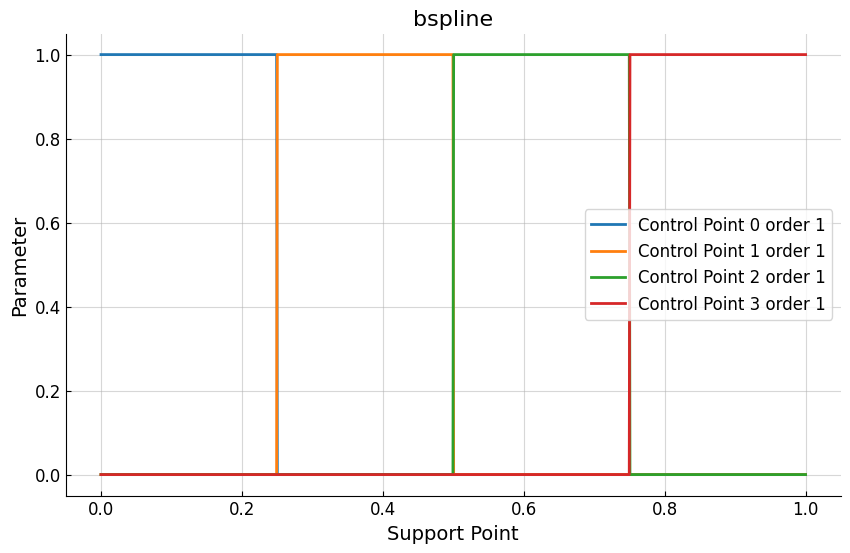

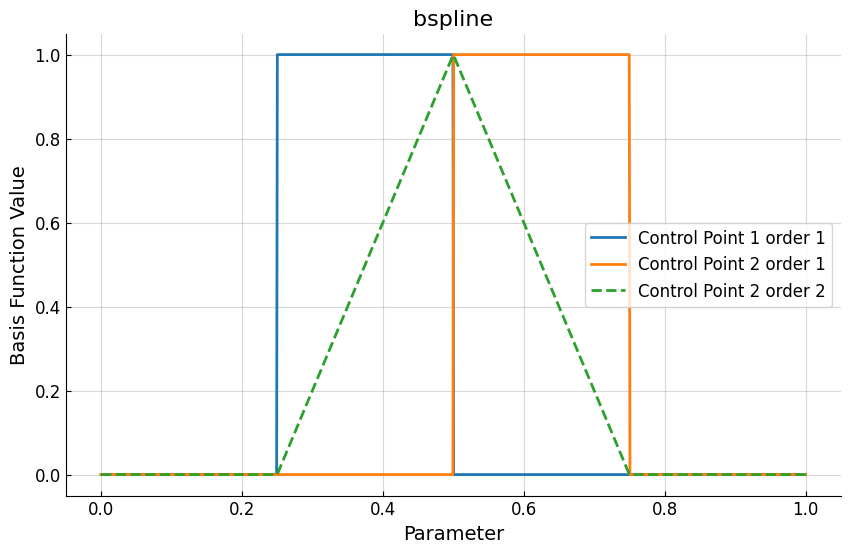

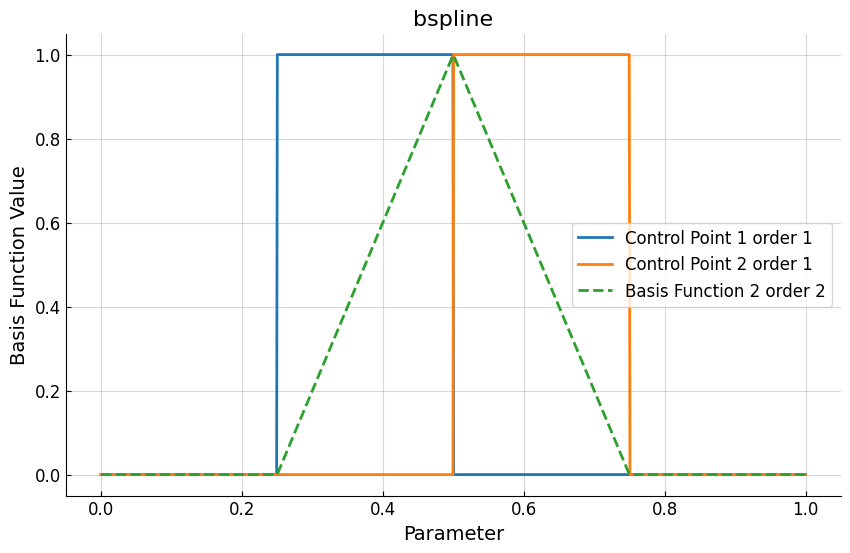

<Figure size 1000x600 with 0 Axes>

In [2]:
from utils.math.BSpline import BSpline
import numpy as np
import matplotlib.pyplot as plt
plt.figure()
control_points = np.array([0,0,0,0])

for i in range(control_points.shape[0]):
    cp = control_points.copy()
    cp[i] = 1
    b_spline = BSpline(cp,order = 1)

    values = np.linspace(0,1,1000)
    out = []
    for s in values:
        out.append(b_spline.evaluate(s))

    out = np.array(out)
    plt.plot(values,out,'-', label = f'Control Point {i} order 1')
    
plt.title('bspline')
plt.xlabel('Support Point')
plt.ylabel('Parameter')
plt.legend()


plt.figure()
control_points = np.array([0,0,0,0])

for i in [1,2]:
    cp = control_points.copy()
    cp[i] = 1
    b_spline = BSpline(cp,order = 1)

    values = np.linspace(0,1,1000)
    out = []
    for s in values:
        out.append(b_spline.evaluate(s))

    out = np.array(out)
    plt.plot(values,out,'-', label = f'Control Point {i} order 1')
control_points = np.array([0,0,0,0,0])
for i in [2]:
# for i in range(control_points.shape[0]):
    cp = control_points.copy()
    cp[i] = 1
    b_spline = BSpline(cp,order =2)

    values = np.linspace(0,1,1000)
    out = []
    for s in values:
        out.append(b_spline.evaluate(s))

    out = np.array(out)
    plt.plot(values,out,'--',label = f'Control Point {i} order 2')

plt.title('bspline')
plt.xlabel('Parameter')
plt.ylabel('Basis Function Value')
plt.legend()
plt.figure()

# plot approaching knots
control_points = np.array([0,0,0,0])
for i in [1,2]:
    cp = control_points.copy()
    cp[i] = 1
    b_spline = BSpline(cp,order = 1)
    # b_spline.knots[2]-=0.25
    # b_spline.knots[3]-=0.25
    values = np.linspace(0,1,1000)
    out = []
    for s in values:
        out.append(b_spline.evaluate(s))

    out = np.array(out)
    plt.plot(values,out,'-', label = f'Control Point {i} order 1')
control_points = np.array([0,0,0,0,0])
for i in [2]:
# for i in range(control_points.shape[0]):
    cp = control_points.copy()
    order = 2
    cp[i] = 1
    b_spline = BSpline(cp,order = 2)
    # b_spline.knots = np.array(np.linspace(0.0, 1, b_spline.number_of_knots).tolist())
    # b_spline.knots = np.array([np.linspace(0.01, 1.0, b_spline.number_of_knots)]).squeeze()
    # b_spline.knots[3]-=0.25
    # b_spline.knots[4]-=0.25
    values = np.linspace(0,1,1000)
    out = []
    for s in values:
        try:
            out.append(b_spline.evaluate(s))
        except:
            pass
    out = np.array(out)
    plt.plot(values,out,'--',label = f'Basis Function {i} order 2')
    # plt.plot(values[:out.shape[0]]/values[out.shape[0]],out,'--',label = f'Control Point {i} order 2')

plt.title('bspline')
plt.xlabel('Parameter')
plt.ylabel('Basis Function Value')
plt.legend()
plt.figure()

[0.]
[0.12575188]
[0.74999775]
[0.12425038]
[0.]
[0.]
[0.5015015]
[0.4984985]
[0.]
[0.]
[1.]
[0.]


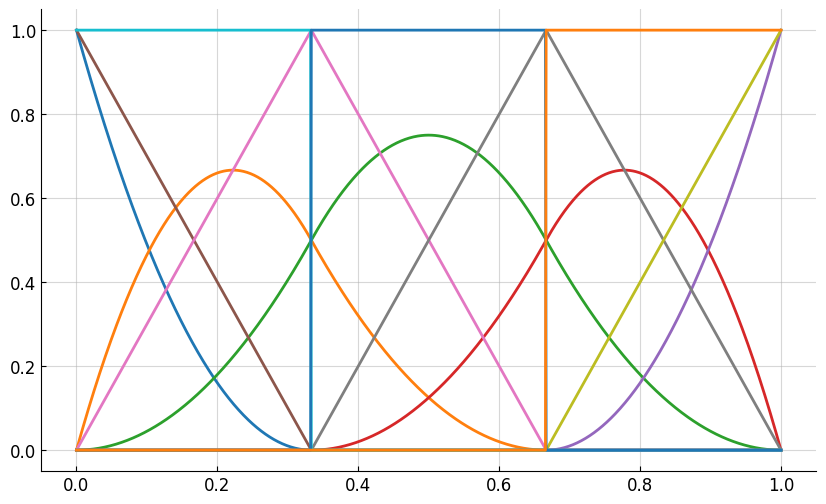

In [3]:
control_points = np.array([0,0,0,0,0])+1
o3 = BSpline(control_points,order = 3)
o2 = o3.create_derivative_spline()
o1 = o2.create_derivative_spline()

for spline in [o3,o2,o1]:
    for i in range(spline.control_points.shape[1]):
        spline.control_points[:] = 0
        spline.control_points[:,i] = 1

        values = np.linspace(0,1,1000)
        out = []
        for s in values:
            if np.allclose(s,0.4994994994994995):
                print(spline.evaluate(s))
            out.append(spline.evaluate(s))

        out = np.array(out)
        plt.plot(values,out,'-', label = f'Control Point {i} order 1')

In [4]:
import casadi as ca
class BSplineFit:
    def __init__(self,num_control_points,order,number_of_positions,number_of_samples):
        
        opti = ca.Opti()
        options = {
            'expand':1, #MX -> SX
            'jit':False,
            'compiler':'shell',
            'print_time':True,
            'jit_options':
                {
                'flags': '-O3 -march=native -shared',
                },
            'ipopt': 
                {
                'print_level': 0, 
                'hessian_approximation': 'exact',
                'linear_solver': 'ma57', 
                'max_iter': 10000,
                'constr_viol_tol':1e-5,
                'max_wall_time':5
                }
            }
        control_points = opti.variable(number_of_positions,num_control_points)
        points_sym = opti.parameter(number_of_positions,number_of_samples)
        self.points_sym = points_sym
        self.order = order
        spline_sol = BSpline(control_points,order=order)
        spline_samples = ca.horzcat(*[spline_sol.evaluate(i) for i in np.linspace(0,1,number_of_samples)])
        obj = ca.sumsqr(points_sym-spline_samples) + ca.sumsqr(ca.diff(spline_samples,1))*10
        opti.subject_to(points_sym[:,0] == spline_samples[:,0])
        opti.subject_to(points_sym[:,1] - points_sym[:,0] == spline_samples[:,1] - spline_samples[:,0])
        opti.minimize(obj)
        opti.solver('ipopt',options)
        self.opti = opti
        self.control_points = control_points
        # sol = opti.solve()
    def solve(self,points):
        self.opti.set_value(self.points_sym,points)
        sol = self.opti.solve()
        return BSpline(sol.value(self.control_points),order=self.order)
    def __call__(self,points):
        return self.solve(points)
fit_bspline = BSplineFit(40,3,1,100)

[4.01256281]
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 116.00us (  7.25us) 114.08us (  7.13us)        16
       nlp_g  |  29.00us (  1.81us)  22.04us (  1.38us)        16
    nlp_grad  |  98.00us ( 14.00us)  96.73us ( 13.82us)         7
  nlp_grad_f  | 321.00us ( 13.37us) 321.72us ( 13.40us)        24
  nlp_hess_l  | 172.00us ( 21.50us) 171.24us ( 21.41us)         8
   nlp_jac_g  |  28.00us (  1.17us)  23.22us (967.50ns)        24
       total  | 735.00us (735.00us) 732.66us (732.66us)         1


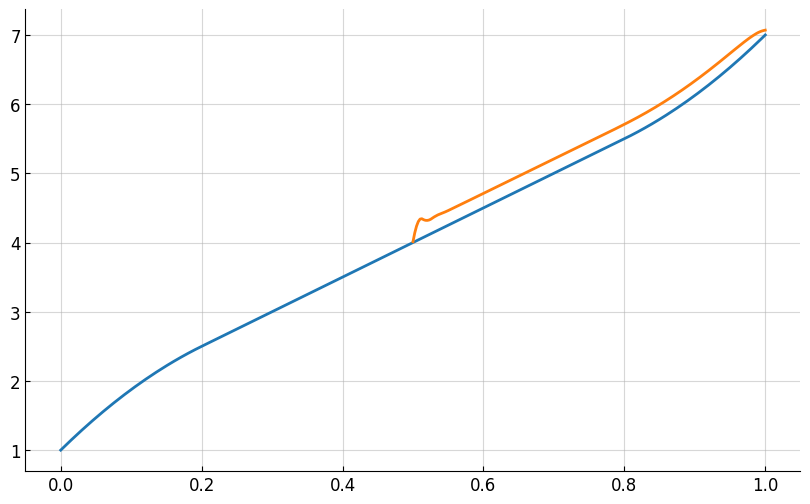

In [15]:

control_points = np.array([1,2,3,4,5,6,7.])
values = []
plt.figure()
o3 = BSpline(control_points,order = 3)
for s in np.linspace(0,1,200):
    values.append(o3.evaluate(s) + np.random.randn()*0.0)
values = np.array(values)
# values[100] += 0.2
plt.plot(np.linspace(0,1,200),values,'-',label = 'Original')
values = values[100:]
values[:] += 0.2
values[0] -=.2
print(values[0])
fitted = fit_bspline(values.T)
# fitted = BSpline(fitted.control_points,order = 3)
values = []
for s in np.linspace(0.0,1,200):
    values.append(fitted.evaluate(s))
values = np.array(values)
plt.plot(np.linspace(0.5,1,200),values,'-',label = 'Fitted')
plt.show()

In [6]:
values

array([[3.97714622],
       [4.05453745],
       [4.10908484],
       [4.1407884 ],
       [4.14964813],
       [4.13566402],
       [4.10791116],
       [4.08760426],
       [4.0756174 ],
       [4.07195057],
       [4.07660377],
       [4.08837839],
       [4.10078995],
       [4.11286758],
       [4.12461129],
       [4.13602106],
       [4.14725516],
       [4.16097913],
       [4.17814644],
       [4.1987571 ],
       [4.2228111 ],
       [4.25030262],
       [4.27891896],
       [4.30677267],
       [4.33386375],
       [4.36019221],
       [4.38575805],
       [4.40931701],
       [4.42843758],
       [4.44305632],
       [4.45317322],
       [4.45878828],
       [4.4605445 ],
       [4.46129549],
       [4.46138136],
       [4.4608021 ],
       [4.45955772],
       [4.45799721],
       [4.46044493],
       [4.46819158],
       [4.48123715],
       [4.49958165],
       [4.52318102],
       [4.54730989],
       [4.56878496],
       [4.58760624],
       [4.60377372],
       [4.617

# Probability thing

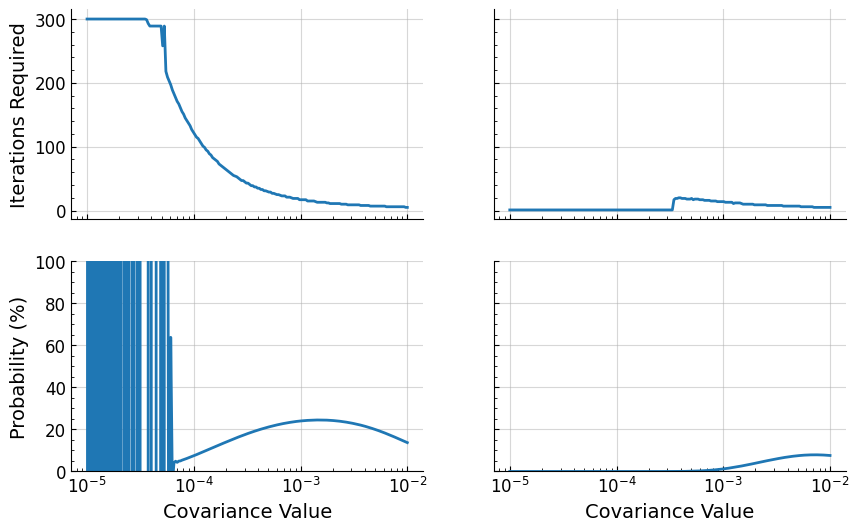

In [7]:
import pickle
import numpy as np
# pickle.dump(probs_given_cov,open('probs_given_cov_point_very_near.p','wb'))
probs_given_cov = pickle.load(open('probs_given_cov_point_very_near.p','rb'))
cov_values = np.logspace(-2,-5,200)
fig,((ax11,ax12), (ax21,ax22)) = plt.subplots(2,2,sharex=True,sharey='row')
iterations_required_by_cov = []
probabilities = []
for i,prob in enumerate(probs_given_cov[:]):
    abs_diff = np.max(np.abs(prob[1:] - prob[:-1]),axis=1)
    index_of_last_number_bigger_than = prob.shape[0] - (np.nonzero(abs_diff[::-1] > 1e-4,)[0][0] if np.any(abs_diff > 1e-4) else prob.shape[0])
    iterations_required_by_cov.append( index_of_last_number_bigger_than + 1)
    probabilities.append(prob[index_of_last_number_bigger_than - 1,39])
    a = abs_diff > 1e-4
    

ax11.plot(np.logspace(-2,-5,200),iterations_required_by_cov)
# ax1.xscale('log')
ax11.set_xscale('log')
# ax11.set_xlabel('Covariance Value')
ax11.set_ylabel('Iterations Required')
ax21.plot(np.logspace(-2,-5,200)[:],np.array(probabilities[:])*100)
ax21.set_xscale('log')
ax21.set_xlabel('Covariance Value')
ax21.set_ylabel('Probability (%)')

probs_given_cov_point_far = pickle.load(open('probs_given_cov_point_far.p','rb'))

iterations_required_by_cov = []
probabilities = []
for i,prob in enumerate(probs_given_cov_point_far[:]):
    abs_diff = np.max(np.abs(prob[1:] - prob[:-1]),axis=1)
    index_of_last_number_bigger_than = prob.shape[0] - (np.nonzero(abs_diff[::-1] > 1e-4,)[0][0] if np.any(abs_diff > 1e-4) else prob.shape[0])
    iterations_required_by_cov.append( index_of_last_number_bigger_than + 1)
    probabilities.append(prob[index_of_last_number_bigger_than - 1,39])
    a = abs_diff > 1e-4
    

ax12.plot(np.logspace(-2,-5,200),iterations_required_by_cov)
# ax1.xscale('log')
# set small ticks grid:

ax21.minorticks_on()
ax22.minorticks_on()
ax11.minorticks_on()
ax12.minorticks_on()
ax12.set_xscale('log')
# ax12.set_xlabel('Covariance Value')
# ax12.set_ylabel('Iterations Required')
ax22.plot(np.logspace(-2,-5,200)[:],np.array(probabilities[:])*100)
ax22.set_xscale('log')
ax22.set_xlabel('Covariance Value')
# ax22.set_ylabel('Probability (%)')
ax22.set_ylim([0,100])
fig.savefig('convergence.png')

## Polytopee building

In [8]:
import torch
import scipy 
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def project_points_onto_plane_torch(points, d):
    # Convert points to a PyTorch tensor if they are not already
    if not isinstance(points, torch.Tensor):
        points = torch.tensor(points, dtype=torch.float32)

    theta = torch.atan2(points[...,0],points[...,2])
    xl = torch.tan(theta)*d
    yl = points[...,1]*d/(points[...,2] * torch.cos(theta)+1e-6)
    new_points = torch.stack([xl, yl, torch.full_like(yl, d)], dim=-1)


    return new_points

from scipy.spatial import ConvexHull
%matplotlib ipympl 
# Generate some random points
points = np.random.randn(50, 3)*0.5
points[:,2] += 4
# Calculate the convex hull
hull = ConvexHull(points)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points[:, 0], points[:, 1], points[:, 2], 'o')

for simplex in hull.simplices:
    simplex = np.append(simplex, simplex[0])  # Repeat the first point to close the polygon
    ax.plot(points[simplex, 0], points[simplex, 1], points[simplex, 2], 'k-')

faces = Poly3DCollection(points[hull.simplices], alpha=0.3, facecolor='cyan')
ax.add_collection3d(faces)
ax.scatter(points[hull.vertices, 0], points[hull.vertices, 1], points[hull.vertices, 2], c='r')


ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
ax.set_title('Convex Hull of the Cluster')
ax.set_proj_type('ortho')
ax.view_init(elev=-18, azim=-58)
ax.set_xlim([-3,3])
ax.set_ylim([-3,3])
ax.set_zlim([3,7])
ax.set_xticks([-3,-1.5,0,1.5,3])
ax.set_yticks([-3,-1.5,0,1.5,3])
ax.set_zticks([3,4,5,6,7])
plt.show()

fig.savefig('polytope_1.png')
fig = plt.figure()
faces = Poly3DCollection(points[hull.simplices], alpha=0.3, facecolor='cyan')
ax = fig.add_subplot(111, projection='3d')
ax.add_collection3d(faces)
ax.scatter(points[hull.vertices, 0], points[hull.vertices, 1], points[hull.vertices, 2], c='r')
projected_vertex = project_points_onto_plane_torch(points[hull.vertices], 7).numpy()

for simplex in hull.simplices:
    simplex = np.append(simplex, simplex[0])  # Repeat the first point to close the polygon
    ax.plot(points[simplex, 0], points[simplex, 1], points[simplex, 2], 'k-',alpha = 0.2,linewidth = 0.5)



hull_proj = ConvexHull(projected_vertex[:,:2])
from concave_hull import convex_hull, convex_hull_indexes
vertices_indices = convex_hull_indexes(projected_vertex[:,:2])
mask = np.zeros(projected_vertex.shape[0],dtype = bool)
mask[vertices_indices] = True
for proj_vertices,vertices in zip(projected_vertex[mask],points[hull.vertices][mask]):
    ax.plot([proj_vertices[0],vertices[0]], [proj_vertices[1],vertices[1]], [proj_vertices[2],vertices[2]], 'k--')
for proj_vertices,vertices in zip(projected_vertex[~mask],points[hull.vertices][~mask]):
    ax.plot([proj_vertices[0],vertices[0]], [proj_vertices[1],vertices[1]], [proj_vertices[2],vertices[2]], 'k--',alpha = 0.25)
ax.scatter(projected_vertex[mask,0],projected_vertex[mask,1],projected_vertex[mask,2], c='g')
ax.scatter(projected_vertex[~mask,0],projected_vertex[~mask,1],projected_vertex[~mask,2], c='purple',alpha = 0.25)

# faces = Poly3DCollection(projected_vertex.reshape(1,-1,3), alpha=1, facecolor='cyan')
# ax.add_collection3d(faces)
import matplotlib.patches as patches
z_value = 0
hull_vertices_3d = np.c_[projected_vertex[vertices_indices], ]
polygon = Poly3DCollection([hull_vertices_3d], alpha=0.3, facecolor='blue', edgecolor='r')

ax.add_collection3d(polygon)
ax.view_init(elev=-18, azim=-58)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
ax.set_title('Project Vertices onto Background')
ax.set_proj_type('ortho')
ax.set_xlim([-3,3])
ax.set_ylim([-3,3])
ax.set_zlim([3,7])
ax.set_xticks([-3,-1.5,0,1.5,3])
ax.set_yticks([-3,-1.5,0,1.5,3])
ax.set_zticks([3,4,5,6,7])
plt.show()

fig.savefig('polytope_2.png')
fig = plt.figure()
# faces = Poly3DCollection(points[hull.simplices], alpha=0.3, facecolor='cyan')
ax = fig.add_subplot(111, projection='3d')
# ax.add_collection3d(faces)

projected_vertex = project_points_onto_plane_torch(points[hull.vertices], 7).numpy()

points_ = points.copy()
points_[:,2] = (points_.min(axis=0)[2] + points_.max(axis=0)[2])/2
hull_proj = ConvexHull(projected_vertex[:,:2])
from concave_hull import convex_hull, convex_hull_indexes
vertices_indices = convex_hull_indexes(projected_vertex[:,:2])
mask = np.zeros(projected_vertex.shape[0],dtype = bool)
mask[vertices_indices] = True
for proj_vertices,vertices in zip(projected_vertex[mask],points_[hull.vertices][mask]):
    ax.plot([proj_vertices[0],vertices[0]], [proj_vertices[1],vertices[1]], [proj_vertices[2],vertices[2]], 'k--')
ax.scatter(projected_vertex[mask,0],projected_vertex[mask,1],projected_vertex[mask,2], c='g')

# faces = Poly3DCollection(projected_vertex.reshape(1,-1,3), alpha=1, facecolor='cyan')
# ax.add_collection3d(faces)
ax.scatter(points_[hull.vertices[mask], 0], points_[hull.vertices[mask], 1], points_[hull.vertices[mask], 2], c='r')
import matplotlib.patches as patches
z_value = 0
hull_vertices_3d = np.c_[projected_vertex[vertices_indices], ]
polygon = Poly3DCollection([hull_vertices_3d], alpha=0.4, facecolor='blue', edgecolor='r')

ax.add_collection3d(polygon)


projected_vertex_masked = projected_vertex[vertices_indices]
points_vertex_masked = points_[hull.vertices][vertices_indices]

faces = []
for i in range(projected_vertex_masked.shape[0]-1):
    a = points_vertex_masked[i]
    b = points_vertex_masked[i+1]
    c = projected_vertex_masked[i + 1]
    d = projected_vertex_masked[i]
    e = points_vertex_masked[i]
    faces.append(np.vstack([a,b,c,d,e]))
a = points_vertex_masked[i+1]
b = points_vertex_masked[0]
c = projected_vertex_masked[0]
d = projected_vertex_masked[i+1]
e = points_vertex_masked[i+1]
faces.append(np.vstack([a,b,c,d,e]))
faces = np.array(faces)
# faces = np.c_[faces,faces[:,0]]
polygon = Poly3DCollection(faces, alpha=0.4, facecolor='blue', edgecolor='r')
ax.add_collection3d(polygon)
polygon = Poly3DCollection(points_vertex_masked.reshape(1,-1,3), alpha=0.4, facecolor='blue', edgecolor='r')
ax.add_collection3d(polygon)
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
ax.set_title('Build Polytope')
ax.set_proj_type('ortho')
ax.view_init(elev=-18, azim=-58)
ax.set_xlim([-3,3])
ax.set_ylim([-3,3])
ax.set_zlim([3,7])
ax.set_xticks([-3,-1.5,0,1.5,3])
ax.set_yticks([-3,-1.5,0,1.5,3])
ax.set_zticks([3,4,5,6,7])
plt.show()
fig.savefig('polytope_3.png')

ImportError: cannot import name 'docstring' from 'matplotlib' (/usr/local/lib/python3.10/dist-packages/matplotlib/__init__.py)

In [ ]:
vertices_indices

array([8, 7, 6, 0, 2], dtype=int32)

In [ ]:
hull_vertices_3d

array([[ 1.5911939 , -1.1654    ,  7.        ],
       [ 2.8253508 ,  0.5955196 ,  7.        ],
       [-0.4413491 ,  2.6820574 ,  7.        ],
       [-2.5326438 , -0.84523034,  7.        ],
       [-0.5632878 , -1.479973  ,  7.        ]], dtype=float32)

In [ ]:
projected_vertex.reshape(1,-1,3)

array([[[-2.5326438 , -0.84523034,  7.        ],
        [-0.04001109, -0.59075886,  7.        ],
        [-0.5632878 , -1.479973  ,  7.        ],
        [ 1.1228037 , -0.57319146,  7.        ],
        [ 0.36222968,  1.7235    ,  7.        ],
        [ 1.1906241 ,  0.98884535,  7.        ],
        [-0.4413491 ,  2.6820574 ,  7.        ],
        [ 2.8253508 ,  0.5955196 ,  7.        ],
        [ 1.5911939 , -1.1654    ,  7.        ],
        [-1.0601658 , -0.39995277,  7.        ],
        [ 1.4115452 ,  0.6855763 ,  7.        ],
        [ 1.0651948 ,  0.07167493,  7.        ],
        [ 0.18739903, -1.2733874 ,  7.        ]]], dtype=float32)